In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv(
'/content/drive/MyDrive/Colab Notebooks/navic_ml_ready.csv'
)

print("Dataset Loaded")
print(df.shape)

df.head()

Dataset Loaded
(86399, 155)


,TOWC (s),Block Count,No of tracked channels,Acquisition status word1,Chan No-1,PRN-1,Channel Tracking Status-1,Doppler-1 (Hz),C/NO-1 (dB-Hz),PR-1 (m),...,NEW Code - Carrier-5 (m),Carrier Delay-6 (meters),Corrected Carrier Range-6 (m),Code - Carrier-6 (m),NEW Code - Carrier-6 (m),Carrier Delay-7 (meters),Corrected Carrier Range-7 (m),Code - Carrier-7 (m),NEW Code - Carrier-7 (m),Predicted_value
0,442800,1283534,7,1403562,1,1,2580,-1615.817017,42.984573,10554080.66,...,13.356979,38279163.48,38279168.00,-10.005910,7.591008,39038691.51,39038696.03,5.816288,28.574394,0
1,442801,1283535,7,1403562,1,1,2580,-1615.728149,42.950333,10554492.96,...,16.739483,38279166.10,38279167.32,-6.976118,10.620826,39038703.95,39038705.17,9.025921,31.784089,0
2,442802,1283536,7,1403562,1,1,2580,-1615.585327,41.682514,10554903.60,...,14.632475,38279168.70,38279171.95,-9.173725,8.423233,39038716.35,39038719.61,7.009730,29.767946,0
3,442803,1283537,7,1403562,1,1,2580,-1615.757813,42.820030,10555316.61,...,12.797277,38279171.05,38279176.11,-10.584458,7.012520,39038728.51,39038733.57,5.203156,27.961414,0
4,442804,1283538,7,1403562,1,1,2580,-1616.135864,42.741901,10555728.47,...,16.698533,38279173.36,38279174.79,-7.292976,10.304016,39038740.62,39038742.05,8.613542,31.371852,0


In [ ]:
features=[

'Satellite X Position-7 (m)',
'Satellite Y Position-7 (m)',
'Satellite Z Position-7 (m)',

'Satellite X Velocity-7 (m/s)',
'Satellite Y Velocity-7 (m/s)',
'Satellite Z Velocity-7 (m/s)',

'Azimuth-7 (deg)',
'Elevation-7 (deg)'
]

targets=[

'Satellite X Position-7 (m)',
'Satellite Y Position-7 (m)',
'Satellite Z Position-7 (m)',

'Azimuth-7 (deg)',
'Elevation-7 (deg)'
]

X=df[features].values
y=df[targets].values

In [ ]:
x_scaler=MinMaxScaler()
y_scaler=MinMaxScaler()

X=x_scaler.fit_transform(X)
y=y_scaler.fit_transform(y)

print(X.shape)
print(y.shape)

(86399, 8)
(86399, 5)


In [ ]:
SEQ_LEN=100

X_seq=[]
y_seq=[]

for i in range(len(X)-SEQ_LEN):

    X_seq.append(
        X[i:i+SEQ_LEN]
    )

    y_seq.append(
        y[i+SEQ_LEN]
    )

X_seq=np.array(X_seq)
y_seq=np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(86299, 100, 8)
(86299, 5)


In [ ]:

X_train,X_temp,y_train,y_temp=train_test_split(

    X_seq,
    y_seq,

    test_size=0.30,
    shuffle=True,
    random_state=42
)

X_val,X_test,y_val,y_test=train_test_split(

    X_temp,
    y_temp,

    test_size=2/3,
    random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (60409, 100, 8)
Validation: (8630, 100, 8)
Test: (17260, 100, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model=Sequential()

model.add(

    SimpleRNN(

        128,

        return_sequences=True,

        input_shape=(

            X_train.shape[1],
            X_train.shape[2]

        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    SimpleRNN(64)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(64,activation='relu')
)

model.add(
    Dense(32,activation='relu')
)

model.add(
    Dense(5)
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100, 128)       │        17,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,293 (141.77 KB)

 Trainable params: 36,293 (141.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(

    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop=EarlyStopping(

    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history=model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=50,

    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 99s 100ms/step - loss: 0.0083 - mae: 0.0601 - val_loss: 0.0014 - val_mae: 0.0322
Epoch 2/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 88s 94ms/step - loss: 0.0016 - mae: 0.0312 - val_loss: 8.9034e-04 - val_mae: 0.0254
Epoch 3/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 91s 96ms/step - loss: 9.5600e-04 - mae: 0.0240 - val_loss: 0.0010 - val_mae: 0.0254
Epoch 4/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 96s 102ms/step - loss: 6.4144e-04 - mae: 0.0196 - val_loss: 5.7656e-04 - val_mae: 0.0204
Epoch 5/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 89s 94ms/step - loss: 4.8966e-04 - mae: 0.0171 - val_loss: 5.0514e-04 - val_mae: 0.0170
Epoch 6/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 91s 96ms/step - loss: 3.9985e-04 - mae: 0.0154 - val_loss: 1.6383e-04 - val_mae: 0.0108
Epoch 7/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 108s 114ms/step - loss: 3.3617e-04 - mae: 0.0140 - val_loss: 1.8640e-04 - val_mae: 0.0101
Epoch 8/50
944/944 ━━━━━━━━━━━━━━━━━━━━ 124s 95ms/step - loss: 2.9699e-04 - mae: 0.0132 - val_loss: 1.7886e-04 - val

In [ ]:
model.save(

"navic_rnn_model.keras"
)

print("Model Saved")

Model Saved


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

predictions=model.predict(X_test)

rmse=np.sqrt(
mean_squared_error(
y_test,
predictions
)
)

mae=mean_absolute_error(
y_test,
predictions
)
accuracy = (1-mae)*100
r2=r2_score(
y_test,
predictions
)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)
print(f"Approx Accuracy : {accuracy:.2f}%")

540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step
RMSE: 0.008191810402207813
MAE: 0.006237047497278642
R2: 0.9993214090601917
Approx Accuracy : 99.38%


In [ ]:
predictions=y_scaler.inverse_transform(
predictions
)

y_test_original=y_scaler.inverse_transform(
y_test
)

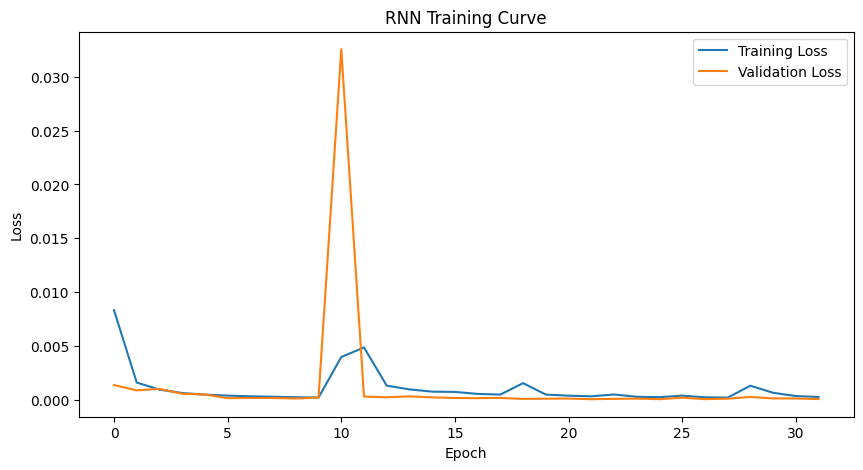

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
history.history['loss'],
label='Training Loss'
)

plt.plot(
history.history['val_loss'],
label='Validation Loss'
)

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
"RNN Training Curve"
)

plt.show()

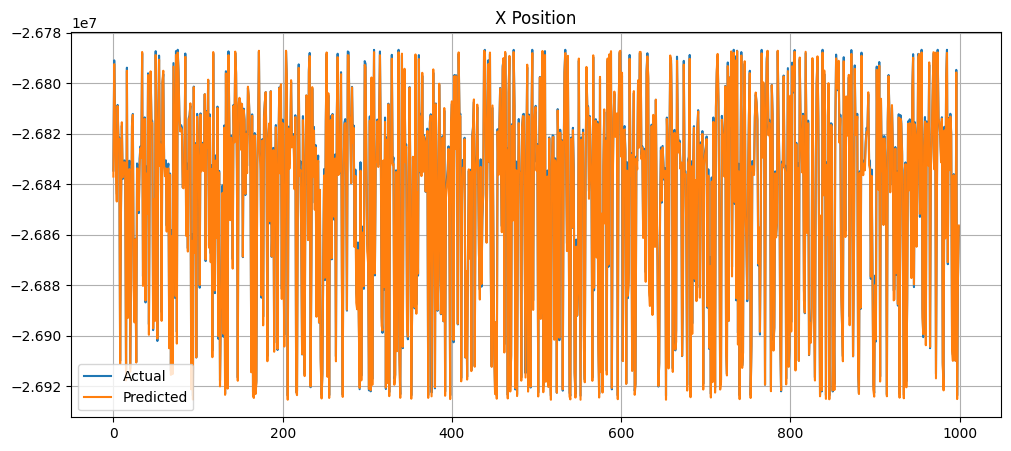

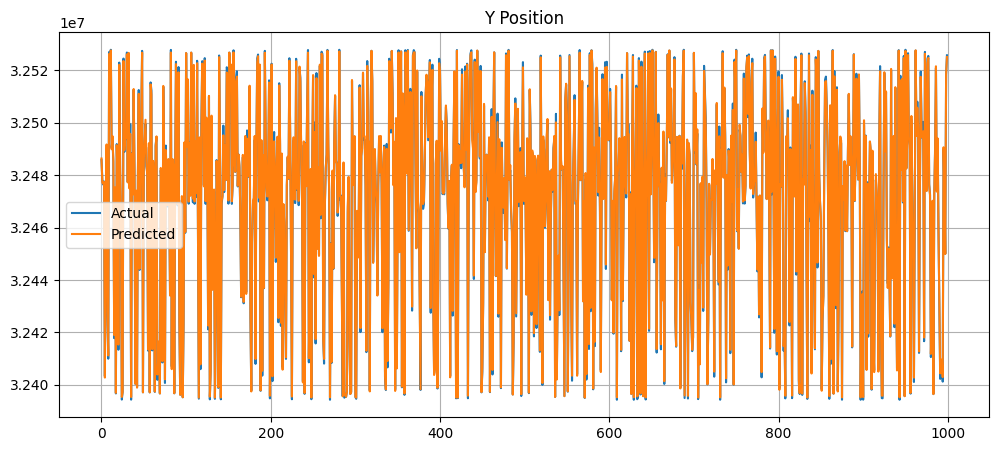

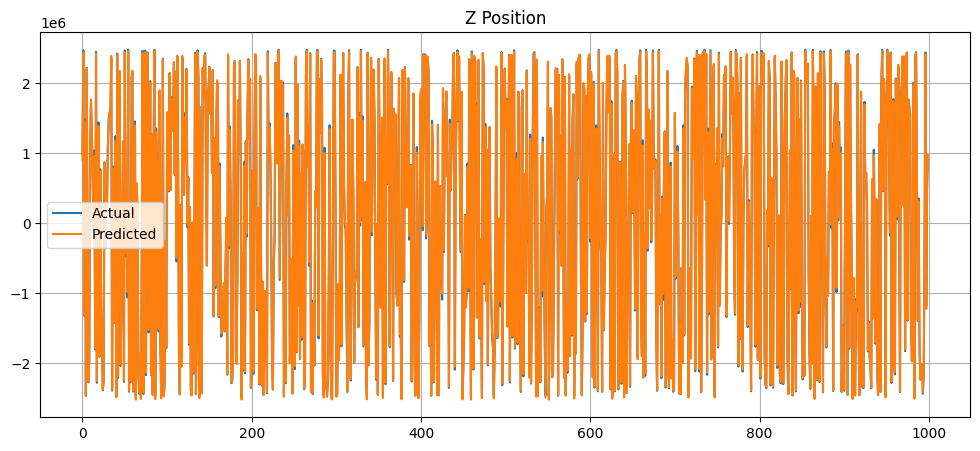

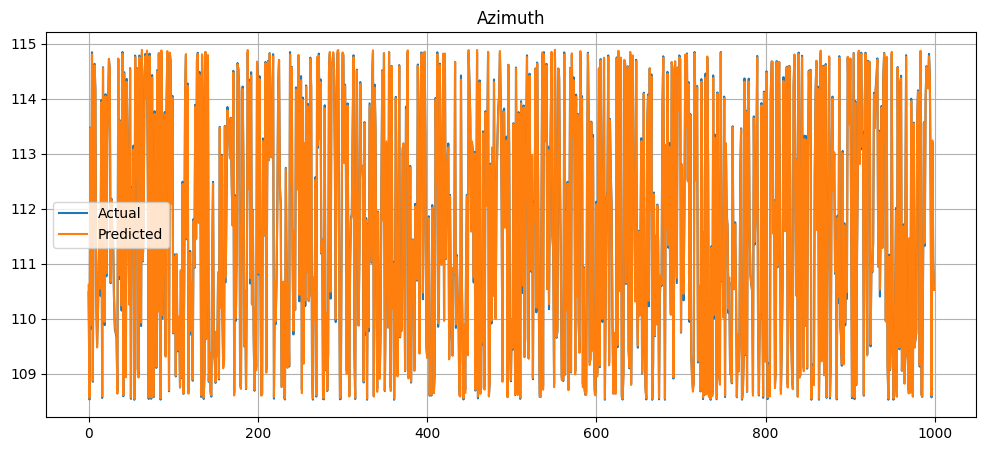

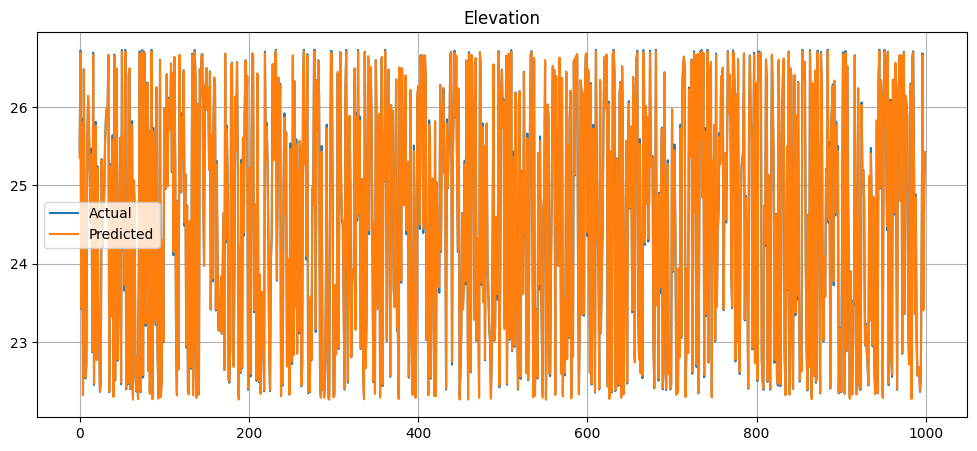

In [ ]:
labels=[

"X Position",
"Y Position",
"Z Position",
"Azimuth",
"Elevation"
]

for i in range(5):

    plt.figure(figsize=(12,5))

    plt.plot(

        y_test_original[:1000,i],
        label='Actual'
    )

    plt.plot(

        predictions[:1000,i],
        label='Predicted'
    )

    plt.legend()

    plt.title(
    labels[i]
    )

    plt.grid()

    plt.show()

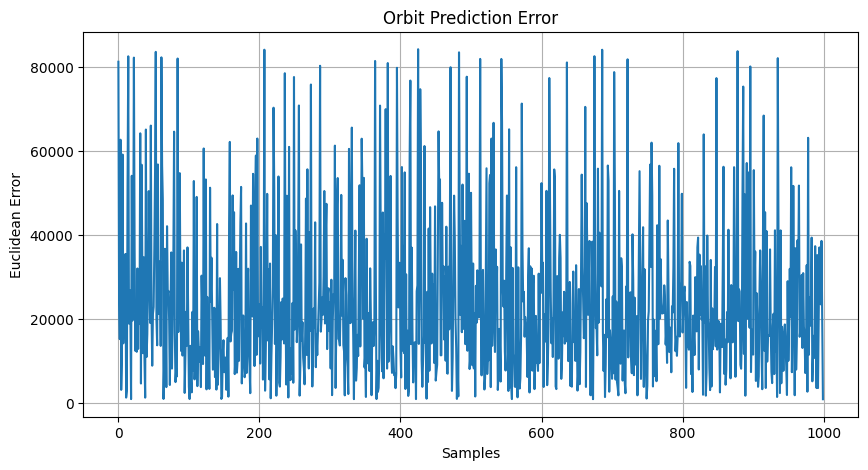

In [ ]:
orbit_error=np.sqrt(

(predictions[:,0]-y_test_original[:,0])**2+

(predictions[:,1]-y_test_original[:,1])**2+

(predictions[:,2]-y_test_original[:,2])**2
)

plt.figure(figsize=(10,5))

plt.plot(
orbit_error[:1000]
)

plt.title(
"Orbit Prediction Error"
)

plt.xlabel("Samples")
plt.ylabel("Euclidean Error")

plt.grid()

plt.show()

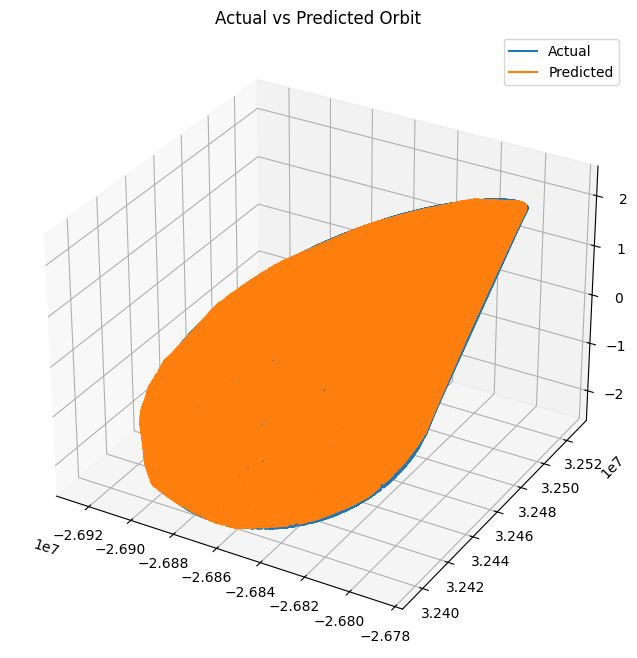

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,8))

ax=fig.add_subplot(
111,
projection='3d'
)

ax.plot(

y_test_original[:2000,0],
y_test_original[:2000,1],
y_test_original[:2000,2],

label='Actual'
)

ax.plot(

predictions[:2000,0],
predictions[:2000,1],
predictions[:2000,2],

label='Predicted'
)

ax.set_title(
"Actual vs Predicted Orbit"
)

ax.legend()

plt.show()